In [ ]:
# --- Colab setup (auto-inserted; no-op outside Colab). tag: colab-bootstrap ---
import sys
if "google.colab" in sys.modules:
    import os, subprocess, pathlib
    _slug = "aniryou/full-stack-agentic-engineer"
    _root = pathlib.Path("/content") / "full-stack-agentic-engineer"
    if not _root.exists():
        subprocess.run(["git", "clone", "--depth", "1", f"https://github.com/{_slug}.git", str(_root)], check=True)
    os.chdir(_root / "07-application-agent-framework/retrieval-rag/embeddings-lab/notebooks")
    for _c in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (_c / "pyproject.toml").exists() or (_c / "setup.py").exists():
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(_c)]); break
        if (_c / "requirements.txt").exists():
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(_c / "requirements.txt")]); break
        if _c == _root:
            break
    if str(pathlib.Path.cwd()) not in sys.path:
        sys.path.insert(0, str(pathlib.Path.cwd()))


# 04 · Vector search from scratch: IVF + PQ
**One idea:** ANN search trades a little recall for a lot of speed and memory,
via two moves — *scan less* (inverted file) and *store less* (product
quantization). We build both in NumPy and finish with the filtered-search
trap. *Primer §13.*

In [1]:
import numpy as np, matplotlib.pyplot as plt
rng = np.random.default_rng(0)

# clustered synthetic "embeddings" — realistic for IVF, unlike pure noise
N, D, NC = 20000, 64, 40
centers = rng.normal(size=(NC, D)) * 3
assign = rng.integers(0, NC, N)
X = centers[assign] + rng.normal(size=(N, D))
NQ = 200
qi = rng.integers(0, N, NQ)
Q = X[qi] + rng.normal(size=(NQ, D)) * 0.3

def l2sq(A, B):                       # pairwise squared distances
    return (A * A).sum(1)[:, None] + (B * B).sum(1)[None, :] - 2 * A @ B.T

gold = np.argsort(l2sq(Q, X), axis=1)[:, :10]     # exact top-10 = recall ceiling
print(f"DB {N}×{D} fp32 = {X.nbytes/1e6:.0f} MB   | brute force does {N} dists/query")

def recall10(found):
    return float(np.mean([len(set(f[:10]) & set(g)) / 10 for f, g in zip(found, gold)]))

DB 20000×64 fp32 = 10 MB   | brute force does 20000 dists/query


## k-means (15 lines) — the workhorse under both IVF and PQ

In [2]:
def kmeans(X, k, iters=15, seed=0):
    r = np.random.default_rng(seed)
    Cc = X[r.choice(len(X), k, replace=False)].copy()
    for _ in range(iters):
        a = np.argmin(l2sq(X, Cc), axis=1)
        for c in range(k):
            m = a == c
            if m.any():
                Cc[c] = X[m].mean(0)
    return Cc, np.argmin(l2sq(X, Cc), axis=1)

## IVF: scan less
Cluster the DB into `n_list` cells; at query time scan only the `n_probe`
nearest cells. Recall vs work is the whole game.

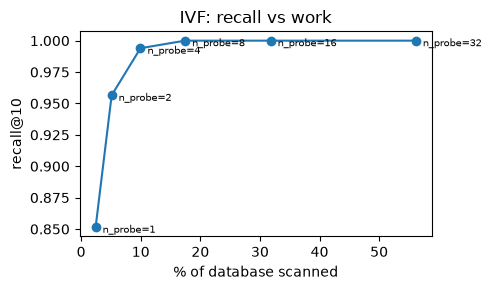

In [3]:
NLIST = 64
cents, cell = kmeans(X, NLIST, seed=1)
lists = [np.where(cell == c)[0] for c in range(NLIST)]

def ivf_search(q, n_probe):
    probe = np.argsort(((cents - q) ** 2).sum(1))[:n_probe]
    cand = np.concatenate([lists[c] for c in probe])
    d = ((X[cand] - q) ** 2).sum(1)
    return cand[np.argsort(d)[:10]], len(cand)

probes = [1, 2, 4, 8, 16, 32]
rec, frac = [], []
for npb in probes:
    out = [ivf_search(q, npb) for q in Q]
    rec.append(recall10([o[0] for o in out]))
    frac.append(np.mean([o[1] for o in out]) / N)
plt.figure(figsize=(5, 3))
plt.plot([f * 100 for f in frac], rec, "o-")
for npb, f, r in zip(probes, frac, rec):
    plt.annotate(f"n_probe={npb}", (f * 100, r), fontsize=7,
                 textcoords="offset points", xytext=(5, -4))
plt.xlabel("% of database scanned"); plt.ylabel("recall@10")
plt.title("IVF: recall vs work"); plt.tight_layout(); plt.show()

## PQ: store less
Split each vector into `m` sub-vectors; k-means each subspace to 256 centroids;
store one **byte** per sub-vector. Query-time distances come from an `m × 256`
lookup table (*asymmetric distance computation*) — no decompression.

In [4]:
M, KS = 8, 256
sub = D // M
codebooks = np.zeros((M, KS, sub))
codes = np.zeros((N, M), dtype=np.uint8)
for m in range(M):
    seg = X[:, m * sub : (m + 1) * sub]
    codebooks[m], a = kmeans(seg, KS, iters=10, seed=10 + m)
    codes[:, m] = a
print(f"compressed DB: {codes.nbytes/1e6:.2f} MB   ({X.nbytes // codes.nbytes}× smaller)")

def adc(q):
    """distance from q to every code via lookup tables."""
    lut = np.stack([((codebooks[m] - q[m * sub : (m + 1) * sub]) ** 2).sum(1)
                    for m in range(M)])                     # (M, 256)
    return lut[np.arange(M)[None, :], codes].sum(1)         # (N,)

def pq_search(q, rerank=0):
    d = adc(q)
    if not rerank:
        return np.argsort(d)[:10]
    cand = np.argsort(d)[:rerank]
    return cand[np.argsort(((X[cand] - q) ** 2).sum(1))[:10]]

r_pq = recall10([pq_search(q) for q in Q])
r_rr = recall10([pq_search(q, rerank=200) for q in Q])
print(f"PQ alone       recall@10 = {r_pq:.3f}")
print(f"PQ + rerank200 recall@10 = {r_rr:.3f}   ← compress, then verify with full vectors")

compressed DB: 0.16 MB   (64× smaller)
PQ alone       recall@10 = 0.236
PQ + rerank200 recall@10 = 0.856   ← compress, then verify with full vectors


## IVF + PQ together, and the summary table

In [5]:
def ivfpq_search(q, n_probe=8, rerank=200):
    probe = np.argsort(((cents - q) ** 2).sum(1))[:n_probe]
    cand = np.concatenate([lists[c] for c in probe])
    lut = np.stack([((codebooks[m] - q[m * sub : (m + 1) * sub]) ** 2).sum(1)
                    for m in range(M)])
    d = lut[np.arange(M)[None, :], codes[cand]].sum(1)
    short = cand[np.argsort(d)[: min(rerank, len(cand))]]
    return short[np.argsort(((X[short] - q) ** 2).sum(1))[:10]], len(cand)

out = [ivfpq_search(q) for q in Q]
rows = [
    ("brute force", 1.000, N, X.nbytes / 1e6),
    (f"IVF n_probe=8", rec[probes.index(8)], int(frac[probes.index(8)] * N), X.nbytes / 1e6),
    ("PQ + rerank", r_rr, N, codes.nbytes / 1e6),
    ("IVF-PQ + rerank", recall10([o[0] for o in out]),
     int(np.mean([o[1] for o in out])), codes.nbytes / 1e6),
]
print(f"{'method':>16} | recall@10 | dists/query | vector MB")
for name, r, dq, mb in rows:
    print(f"{name:>16} | {r:9.3f} | {dq:11,d} | {mb:9.2f}")

          method | recall@10 | dists/query | vector MB
     brute force |     1.000 |      20,000 |     10.24
   IVF n_probe=8 |     1.000 |       3,488 |     10.24
     PQ + rerank |     0.856 |      20,000 |      0.16
 IVF-PQ + rerank |     0.856 |       3,488 |      0.16


## The filtered-search trap
Real queries carry predicates (tenant, ACL, date). **Post-filtering** — search
first, drop non-matching — collapses when the filter is selective, because the
top-k may contain zero matches. **Pre-filtering** searches only the matching
set and is exact.

In [6]:
TAGS = 100
tag = rng.integers(0, TAGS, N)                 # ~1% selectivity per tag
want = (tag[qi] + 1) % TAGS       # a tag the query's nearest points do NOT carry

def filtered_gold(q, t):           # exact pre-filtered search (the right answer)
    idx = np.where(tag == t)[0]
    return idx[np.argsort(((X[idx] - q) ** 2).sum(1))[:10]]

def post_filter(q, t, k_search=100):
    top = np.argsort(((X - q) ** 2).sum(1))[:k_search]
    return top[tag[top] == t][:10]

recs, empty = [], 0
for q, t in zip(Q, want):
    found = post_filter(q, t)
    empty += len(found) == 0
    recs.append(len(set(found) & set(filtered_gold(q, t))) / 10)
print(f"post-filter (search 100, then filter): recall@10 = {np.mean(recs):.3f}, "
      f"{empty}/{NQ} queries return NOTHING at all")
print("pre-filter  (exact over the ~1% matching set): recall@10 = 1.000, "
      f"~{N // TAGS} dists/query — cheaper than the unfiltered search!")

post-filter (search 100, then filter): recall@10 = 0.097, 68/200 queries return NOTHING at all
pre-filter  (exact over the ~1% matching set): recall@10 = 1.000, ~200 dists/query — cheaper than the unfiltered search!


**Takeaways.** (1) Recall-vs-work curves, not single numbers. (2) Compression
(PQ/int8/binary) pairs with cheap **re-ranking** by full vectors. (3) Selective
filters break post-filtering — use pre-filtering, filter-aware traversal, or
partitioning. HNSW/DiskANN change the "scan less" step to graph walks; the
trade-offs are the same shape. → `exercises/ex04.ipynb`.